# BÀI TẬP LỚN SỐ 1: MULTIMODAL CLASSIFICATION
* **Môn học:** Học sâu và ứng dụng trong thị giác máy tính
* **Nhóm:** group6
* **Dataset**: Flickr30k

## Giới thiệu về mô hình CLIP (Contrastive Language-Image Pre-training)

CLIP là mô hình được OpenAI giới thiệu vào năm 2021, đánh dấu bước ngoặt trong việc kết hợp giữa Thị giác máy tính (Computer Vision) và Xử lý ngôn ngữ tự nhiên (NLP). 

Điểm yếu của các mô hình phân loại truyền thống (như ResNet) là chúng bị bó hẹp trong một bộ nhãn cố định (ví dụ: 1000 lớp của ImageNet). Nếu muốn nhận diện một vật thể mới, ta phải thu thập dữ liệu và train lại lớp cuối. CLIP giải quyết vấn đề này bằng cách học từ **400 triệu cặp hình ảnh - văn bản** trên Internet.

### 1. Kiến trúc cốt lõi: Học tương phản (Contrastive Learning)

CLIP không cố gắng dự đoán "đây là con mèo". Thay vào đó, nó học cách **nối kết** giữa một mô tả văn bản và một bức ảnh tương ứng.

* **Cấu trúc gồm hai phần (Two-tower architecture):**
    * **Image Encoder:** Có thể là ResNet hoặc Vision Transformer (ViT), dùng để chuyển hình ảnh thành một vector đặc trưng (embedding).
    * **Text Encoder:** Một mô hình Transformer, dùng để chuyển câu văn thành một vector đặc trưng cùng kích thước với vector ảnh.
* **Cơ chế hoạt động:** Trong một batch gồm $N$ cặp (ảnh, văn bản), CLIP sẽ cực đại hóa độ tương đồng (cosine similarity) của $N$ cặp đúng và cực tiểu hóa độ tương đồng của $N^2 - N$ cặp sai.


---

### 2. Zero-shot Classification

Đây là khả năng "bá đạo" nhất của CLIP: Phân loại hình ảnh mà không cần xem qua bất kỳ ví dụ nào của lớp đó trong quá trình training.

**Quy trình thực hiện:**
1.  **Tạo Prompt:** Thay vì dùng nhãn đơn lẻ như "dog", ta đưa vào một template prompt như: *"A photo of a [label]"*.
2.  **Vector hóa nhãn:** Tất cả các tên lớp (labels) tiềm năng sẽ được đưa qua Text Encoder để tạo ra các vector embedding văn bản.
3.  **So khớp:** Khi có một ảnh mới, ảnh đó được đưa qua Image Encoder. CLIP sẽ tính toán xem vector ảnh này "gần" với vector của nhãn nào nhất trong không gian vector. Nhãn có độ tương đồng cao nhất sẽ là kết quả dự đoán.

> Zero-shot biến bài toán phân loại (Classification) thành bài toán tìm kiếm ngữ nghĩa (Semantic Search).

---

### 3. Few-shot Classification với Linear Probing (Logistic Regression)

Trong trường hợp ta có một ít dữ liệu thực tế (vài ví dụ cho mỗi lớp) và muốn tối ưu hóa độ chính xác hơn nữa cho một domain cụ thể, ta sử dụng phương pháp **Linear Probing**.

**Cách hoạt động:**
* **Đóng băng (Freeze):** Ta giữ nguyên toàn bộ trọng số của CLIP (cả Image và Text Encoder). Chúng ta coi CLIP như một bộ trích xuất đặc trưng (Feature Extractor) cực mạnh.
* **Trích xuất đặc trưng:** Đưa tập dữ liệu nhỏ của ta qua Image Encoder để thu về các vector đặc trưng.
* **Huấn luyện bộ phân loại tuyến tính:** Sử dụng một thuật toán học máy đơn giản, thường là **Logistic Regression**, để học cách phân loại các vector đặc trưng này vào các nhãn mong muốn.

**Tại sao dùng Logistic Regression?**
Vì đặc trưng từ CLIP đã rất tốt và có tính phân tách cao, một mặt phẳng (linear) đơn giản là đủ để phân loại. Việc này cực kỳ nhanh, không đòi hỏi GPU khủng và tránh được hiện tượng Overfitting khi dữ liệu ít.

---

## Giới thiệu bộ dữ liệu Flickr30k

Flickr30k là một bộ dữ liệu tiêu chuẩn trong các bài toán Image Captioning và Multi-modal Retrieval (tìm kiếm đa phương thức).

* **Quy mô:** Bao gồm **31,783 hình ảnh** được thu thập từ trang web Flickr.
* **Đặc điểm nổi bật:** Mỗi hình ảnh không chỉ có một nhãn đơn lẻ, mà đi kèm với **5 câu mô tả (captions)** khác nhau do con người viết. 
    * Việc có 5 câu mô tả giúp mô hình học được nhiều cách diễn đạt khác nhau cho cùng một thực thể thị giác (ví dụ: một người có thể mô tả "con chó đang chạy", người khác lại viết "con thú cưng màu nâu trên thảm cỏ").
* **Tính ứng dụng:** * Kiểm tra khả năng hiểu ngữ cảnh phức tạp của mô hình (không chỉ là vật thể mà còn là hành động, màu sắc, mối quan hệ không gian).
    * Làm benchmark để so sánh độ hiệu quả của CLIP so với các phương pháp truyền thống.

| Thuộc tính | Chi tiết |
| :--- | :--- |
| Số lượng ảnh | 31,783 |
| Số lượng chú thích | ~158,915 (5 captions/ảnh) |
| Định dạng chú thích | Tiếng Anh, mô tả hành động và thực thể |
| Nguồn dữ liệu | [Kaggle - Flickr Image Dataset](https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset) |

---

## Các thông số đánh giá hiệu năng 

Trong các bài toán phân loại hình ảnh sử dụng CLIP (Zero-shot hoặc Linear Probing), chúng ta cần những thước đo phản ánh đúng khả năng tổng quát hóa của mô hình.

### 1. Accuracy (Độ chính xác tổng thể)

Accuracy là chỉ số phổ biến nhất, tính bằng tỉ lệ giữa số lượng mẫu dự đoán đúng trên tổng số mẫu.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

* **Ý nghĩa:** Cho biết khả năng phân loại đúng "nhìn chung" của CLIP trên toàn bộ tập dữ liệu Flickr30k.
* **Điểm yếu:** Accuracy cực kỳ "nguy hiểm" nếu tập dữ liệu của ta bị lệch. 
    * *Ví dụ:* Nếu tập test có 90 ảnh là "người" và 10 ảnh là "chó". Một mô hình "ngu ngơ" luôn dự đoán là "người" vẫn đạt Accuracy 90%, nhưng thực tế nó không hề biết nhận diện "chó". 
    * Trong Flickr30k, các thực thể xuất hiện không đồng đều, nên Accuracy chỉ là điều kiện cần, không phải điều kiện đủ.

### 2. Macro-F1 Score

Để hiểu Macro-F1, trước hết ta cần nắm lại **F1-Score** cho từng lớp (Class-wise F1). F1-Score là trung bình điều hòa giữa Precision (Độ chính xác) và Recall (Độ bao phủ).

**Macro-F1** được tính bằng cách lấy trung bình cộng của F1-Score từ tất cả các lớp:

$$\text{Macro-F1} = \frac{1}{N} \sum_{i=1}^{N} F1_i$$

* **Tại sao lại dùng "Macro"?** Chỉ số này đối xử với mọi lớp có **vai trò ngang nhau**, bất kể lớp đó có nhiều hay ít dữ liệu.
* **Ý nghĩa trong báo cáo:** * Nếu **Accuracy cao** nhưng **Macro-F1 thấp**: Nghĩa là CLIP chỉ đang làm tốt ở các lớp phổ biến và đang "tạch" ở các lớp hiếm (minority classes).
    * Nếu cả hai đều cao: Mô hình của ta thực sự ổn định và nhận diện tốt đa dạng các khái niệm trong ảnh.

| Chỉ số | Đặc điểm chính | Phản ánh điều gì? |
| :--- | :--- | :--- |
| **Accuracy** | Chú tâm vào *số lượng* | Hiệu suất khai thác tổng thể trên tập dữ liệu. |
| **Macro-F1** | Chú tâm vào *sự công bằng* | Khả năng nhận diện các khái niệm hiếm/khó trong Flickr30k. |

> Đối với CLIP Zero-shot, Macro-F1 quan trọng hơn Accuracy. Vì Zero-shot vốn dĩ là để kiểm tra khả năng "hiểu" thế giới một cách tổng quát, nếu nó chỉ đúng ở các lớp dễ mà sai sạch ở các lớp khó, thì sức mạnh thực sự của Contrastive Learning chưa được phát huy.

---


## Chuẩn bị môi trường

In [1]:
%pip install transformers torch scikit-learn pillow tqdm pandas numpy matplotlib seaborn kagglehub 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

### Tải dữ liệu bằng Kaggle Hub

In [3]:
import kagglehub
import os

# Download the latest version
path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")

# Scan the directory to find the exact path of results.csv
csv_path = ""
image_path = ""
for root, dirs, files in os.walk(path):
    if "results.csv" in files:
        csv_path = os.path.join(root, "results.csv")
        image_path = os.path.join(root, "flickr30k_images/")
        break

print(f"CSV path: {csv_path}\nFolder images path: {image_path}\n")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

CSV path: /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv
Folder images path: /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images/

Using cuda


### Tải mô hình CLIP

In [4]:
import torch.nn as nn

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
print("Đã tải xong mô hình CLIP")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Đã tải xong mô hình CLIP


## Các bước EDA

### Tải dữ liệu

In [5]:
df = pd.read_csv(csv_path, sep='|')
df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [6]:
# Loại bỏ Na
df = df.dropna()

Vì `df.columns` có chứa hai cột có khoảng trắng (`' comment_number', ' comment'`) nên ta cần `strip`

In [7]:
print("Trước: ", df.columns)
df.columns = df.columns.str.strip()
print("Sau: ", df.columns)

Trước:  Index(['image_name', ' comment_number', ' comment'], dtype='object')
Sau:  Index(['image_name', 'comment_number', 'comment'], dtype='object')


### Thống kê tần suất từ vựng (Word Frequency)

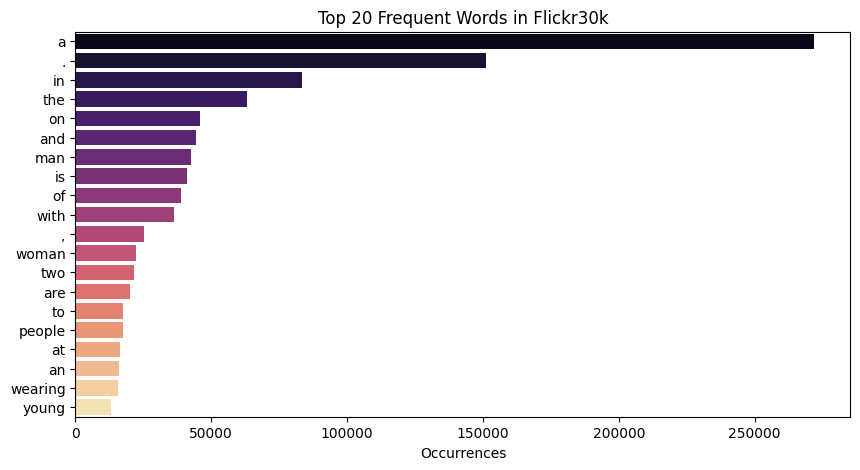

In [8]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten all captions into a single list of lowercase words
all_words = ' '.join(df['comment'].astype(str)).lower().split()
word_counts = Counter(all_words)
words, counts = zip(*word_counts.most_common(20))

# Plot the 20 most frequent words
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title('Top 20 Frequent Words in Flickr30k')
plt.xlabel('Occurrences')
plt.show()

### Phân tích độ dài câu

Recommended MAX_SEQ_LEN: 23


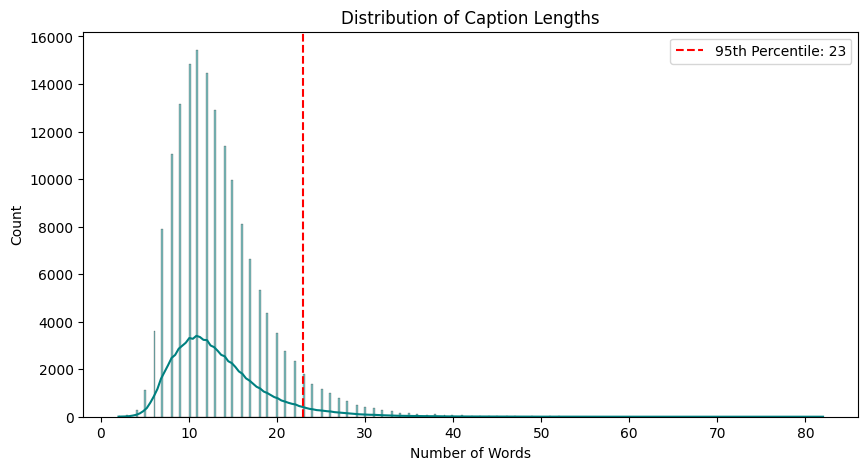

In [9]:
# Calculate word count for each caption entry
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))

# Calculate the 95th percentile for optimal sequence length
p95 = int(df['word_count'].quantile(0.95))
print(f"Recommended MAX_SEQ_LEN: {p95}")

# Plotting the length distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], kde=True, color='teal')
plt.axvline(p95, color='red', linestyle='--', label=f'95th Percentile: {p95}')
plt.title('Distribution of Caption Lengths')
plt.xlabel('Number of Words')
plt.legend()
plt.show()

## Tiền xử lý dữ liệu

In [10]:
import re

def clean_text(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove punctuation and numbers using regex
    # Only keep alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra whitespaces
    text = " ".join(text.split())
    return text

# Apply the cleaning function to create 'clean_caption' column
df['clean_caption'] = df['comment'].apply(clean_text)

# Check the result before building vocabulary
print(f"Raw: {df['comment'].iloc[0]}")
print(f"Cleaned: {df['clean_caption'].iloc[0]}")
df.head()

Raw:  Two young guys with shaggy hair look at their hands while hanging out in the yard .
Cleaned: two young guys with shaggy hair look at their hands while hanging out in the yard


,image_name,comment_number,comment,word_count,clean_caption
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...,17,two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many...",11,two young white males are outside near many bu...
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .,11,two men in green shirts are standing in a yard
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .,11,a man in a blue shirt standing in a garden
4,1000092795.jpg,4,Two friends enjoy time spent together .,7,two friends enjoy time spent together


In [11]:
df_grouped = df.groupby('image_name')['clean_caption'].first().reset_index()
df_grouped.columns = ['image', 'caption']

print(f"Các cột sau khi làm sạch: {df_grouped.columns.tolist()}")
df_grouped.head()

Các cột sau khi làm sạch: ['image', 'caption']


,image,caption
0,1000092795.jpg,two young guys with shaggy hair look at their ...
1,10002456.jpg,several men in hard hats are operating a giant...
2,1000268201.jpg,a child in a pink dress is climbing up a set o...
3,1000344755.jpg,someone in a blue shirt and hat is standing on...
4,1000366164.jpg,two men one in a gray shirt one in a black shi...


In [12]:
# Lọc ảnh tồn tại
valid_rows = []
for idx, row in df_grouped.iterrows():
    img_path = os.path.join(image_path, row['image'])
    if os.path.exists(img_path):
        valid_rows.append({
            'path': img_path,
            'caption': row['caption'],
            'image_name': row['image']
        })


df_valid = pd.DataFrame(valid_rows)
print(f"Tổng số ảnh hợp lệ: {len(df_valid)}")

Tổng số ảnh hợp lệ: 31783


In [13]:
# Định nghĩa nhãn và regex tương ứng
LABEL_MAP = {
    "man": r"\b(man|men|guy|guys|boy|boys|male)\b",
    "dog": r"\b(dog|dogs|puppy|puppies)\b",
    "car": r"\b(car|cars|vehicle|autos)\b",
    "bike": r"\b(bike|bikes|bicycle|bicycles|motorcycle)\b",
    "woman": r"\b(woman|women|girl|girls|lady|ladies|female)\b",
    "water": r"\b(water|ocean|sea|lake|river|pool|beach|surf|shore)\b",
    "tree": r"\b(tree|trees|forest|woods|grass|field|garden|nature|plant)\b",
    "building": r"\b(building|house|skyscraper|street|sidewalk|city|structure|wall)\b",
    "ball": r"\b(ball|basketball|soccer|football|baseball|tennis|volleyball)\b",
}

TARGET_CLASSES = list(LABEL_MAP.keys())
print(TARGET_CLASSES)

# Pre-compile regex
COMPILED_REGEX = {cls: re.compile(pattern, re.IGNORECASE) for cls, pattern in LABEL_MAP.items()}

def assign_label(caption):
    if not isinstance(caption, str):
        return None
    
    counts = {}
    for cls, pattern in COMPILED_REGEX.items():
        # Tìm tất cả các khớp (matches)
        matches = pattern.findall(caption)
        if matches:
            counts[cls] = len(matches)
    
    if not counts:
        return None
        
    # Trả về class có số lần xuất hiện nhiều nhất
    return max(counts, key=counts.get)

['man', 'dog', 'car', 'bike', 'woman', 'water', 'tree', 'building', 'ball']


In [14]:
# Áp dụng hàm gán nhãn
df_valid['label'] = df_valid['caption'].apply(assign_label)
df_clean = df_valid.dropna(subset=['label']).reset_index(drop=True)

print(f"Số lượng ảnh sau lọc: {len(df_clean)}")
if not df_clean.empty:
    print(df_clean['label'].value_counts())

Số lượng ảnh sau lọc: 26297
label
man         13042
woman        6190
dog          1806
building     1567
water        1096
ball          957
tree          699
bike          574
car           366
Name: count, dtype: int64


### Zero-shot Classification với CLIP

In [15]:
from torch.utils.data import Dataset, DataLoader

# Tạo Dataset và DataLoader cho giai đoạn Zero-shot
class FlickrDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['path']).convert("RGB")
            pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
            caption = str(row['caption']) 
            label = row['label']
            return pixel_values, caption, label
        except Exception:
            return None, None, None

# Custom collate_fn để bỏ qua các mẫu lỗi
def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

# Hàm chạy zero-shot benchmark
@torch.no_grad()
def run_zero_shot_bench(df, model, processor, target_classes, templates, batch_size=32):
    device = next(model.parameters()).device
    
    print("Pre-computing text features...")
    text_features_list = []
    for cls in target_classes:
        cls_texts = [tmpl.format(cls) for tmpl in templates]
        inputs = processor(text=cls_texts, return_tensors="pt", padding=True).to(device)
        # Lấy embedding và chuẩn hóa ngay
        embeds = model.get_text_features(**inputs)
        embeds = embeds.pooler_output
        embeds = embeds / (embeds.norm(dim=-1, keepdim=True) + 1e-8)
        # Trung bình cộng các templates của cùng 1 class để tạo 1 vector đại diện duy nhất
        text_features_list.append(embeds.mean(dim=0, keepdim=True))
    
    # Shape: [num_classes, embed_dim]
    final_text_features = torch.cat(text_features_list, dim=0)
    final_text_features /= (final_text_features.norm(dim=-1, keepdim=True) + 1e-8)

    # --- PHASE 2: BATCH INFERENCE ---
    dataset = FlickrDataset(df, processor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, 
                            num_workers=4, collate_fn=collate_fn)

    all_preds = []
    all_trues = []

    for images, caption, labels in tqdm(dataloader, desc="Zero-Shot Batching"):
        if images is None: continue
        
        images = images.to(device)
        # Trích xuất image features
        image_features = model.get_image_features(pixel_values=images)
        image_features = image_features.pooler_output
        image_features = image_features / (image_features.norm(dim=-1, keepdim=True) + 1e-8)

        # Tính Similarity matrix: [batch_size, num_classes]
        # Công thức: S = I \cdot T^T
        logits = image_features @ final_text_features.T
        
        # Lấy index của class cao nhất
        preds_idx = logits.argmax(dim=-1).cpu().numpy()
        
        all_preds.extend([target_classes[i] for i in preds_idx])
        all_trues.extend(labels)

    acc = accuracy_score(all_trues, all_preds)
    f1 = f1_score(all_trues, all_preds, average='macro')
    print(f"\nZero-Shot Accuracy: {acc:.4f}. Macro-F1: {f1}")
    print(classification_report(all_trues, all_preds))
    
    return acc, f1

In [16]:
# Chạy zero-shot benchmark
templates = [
    "a photo of a {}",
    "a picture of a {}",
    "an image of a {}",
    "i see a {}"
]
zero_shot_accuracy, zero_shot_f1_score = run_zero_shot_bench(df_clean, model, processor, TARGET_CLASSES, templates, batch_size=128)

Pre-computing text features...


Zero-Shot Batching:   0%|          | 0/206 [00:00<?, ?it/s]


Zero-Shot Accuracy: 0.6008. Macro-F1: 0.4757917338107088
              precision    recall  f1-score   support

        ball       0.29      0.77      0.42       957
        bike       0.27      0.91      0.42       574
    building       0.36      0.27      0.31      1567
         car       0.24      0.57      0.34       366
         dog       0.75      0.91      0.82      1806
         man       0.85      0.53      0.65     13042
        tree       0.28      0.16      0.20       699
       water       0.36      0.57      0.44      1096
       woman       0.63      0.75      0.69      6190

    accuracy                           0.60     26297
   macro avg       0.45      0.60      0.48     26297
weighted avg       0.69      0.60      0.61     26297



In [17]:
# --- Few-Shot Classification ---
@torch.no_grad()
def get_embeddings(df, model, processor, batch_size=32):
    """Trích xuất embedding theo batch, tối ưu GPU và CPU I/O"""
    device = next(model.parameters()).device
    dataset = FlickrDataset(df, processor)
    dataloader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=4, 
        collate_fn=collate_fn
    )

    all_vecs = []
    all_labels = []

    model.eval()
    for images, captions, labels in tqdm(dataloader, desc="Extracting Multimodal Features"):
        # 1. Xử lý Ảnh
        image_inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
        image_outputs = model.get_image_features(**image_inputs) 
        img_emb = image_outputs.pooler_output if hasattr(image_outputs, 'pooler_output') else image_outputs
        img_emb = img_emb / (img_emb.norm(dim=-1, keepdim=True) + 1e-8)

        # 2. Xử lý Văn bản (Captions)
        text_inputs = processor(text=captions, return_tensors="pt", padding=True, truncation=True).to(device)
        text_outputs = model.get_text_features(**text_inputs)
        txt_emb = text_outputs.pooler_output if hasattr(text_outputs, 'pooler_output') else text_outputs
        txt_emb = txt_emb / (txt_emb.norm(dim=-1, keepdim=True) + 1e-8)

        # 3. Kết hợp (Fusion): Nối hai vector lại thành một vector dài gấp đôi
        # Kích thước sẽ là [batch, 512 + 512] = [batch, 1024]
        multimodal_emb = torch.cat([img_emb, txt_emb], dim=-1)
        
        all_vecs.append(multimodal_emb.cpu().numpy())
        all_labels.extend(labels)

    return np.vstack(all_vecs), all_labels


print("\nBắt đầu Few-Shot Classification")

SHOTS_PER_CLASS = 128
train_list = []
test_list = []

# 1. Chuẩn bị dữ liệu (Data Splitting)
for cls in TARGET_CLASSES:
    cls_df = df_clean[df_clean['label'] == cls]
    if len(cls_df) < SHOTS_PER_CLASS + 5:
        print(f"Bỏ qua lớp {cls}: Chỉ có {len(cls_df)} mẫu.")
        continue
    
    shuffled = cls_df.sample(frac=1, random_state=42)
    train_list.append(shuffled.iloc[:SHOTS_PER_CLASS])
    test_list.append(shuffled.iloc[SHOTS_PER_CLASS:])

if not train_list:
    raise RuntimeError("Không có đủ dữ liệu cho bất kỳ lớp nào!")

df_train = pd.concat(train_list).reset_index(drop=True)
df_test = pd.concat(test_list).reset_index(drop=True)

# 2. Trích xuất đặc trưng (Batch Processing)
print(f"Đang xử lý Train set ({len(df_train)} ảnh)...")
X_train, y_train = get_embeddings(df_train, model, processor, batch_size=256)

print(f"Đang xử lý Test set ({len(df_test)} ảnh)...")
X_test, y_test = get_embeddings(df_test, model, processor, batch_size=256)


Bắt đầu Few-Shot Classification
Đang xử lý Train set (1152 ảnh)...


Extracting Multimodal Features:   0%|          | 0/5 [00:00<?, ?it/s]

Đang xử lý Test set (25145 ảnh)...


Extracting Multimodal Features:   0%|          | 0/99 [00:00<?, ?it/s]

In [18]:
# 3. Huấn luyện Logistic Regression
print("Đang huấn luyện Linear Classifier...")
clf = LogisticRegression(
    max_iter=1000, 
    solver='lbfgs',
    class_weight='balanced',
    C=1.0
)
clf.fit(X_train, y_train)

Đang huấn luyện Linear Classifier...


LogisticRegression(class_weight='balanced', max_iter=1000)

In [19]:
# 4. Đánh giá
y_pred = clf.predict(X_test)
fs_accuracy = accuracy_score(y_test, y_pred)
fs_f1_score = f1_score(y_test, y_pred, average='macro')
print(f"\nFew-Shot ({SHOTS_PER_CLASS} shots) Accuracy: {fs_accuracy:.4f}. Macro-F1: {fs_f1_score:.4f}")
print(classification_report(y_test, y_pred))


Few-Shot (128 shots) Accuracy: 0.7429. Macro-F1: 0.6399
              precision    recall  f1-score   support

        ball       0.56      0.88      0.68       829
        bike       0.37      0.94      0.53       446
    building       0.44      0.79      0.56      1439
         car       0.31      0.84      0.45       238
         dog       0.84      0.96      0.90      1678
         man       0.97      0.65      0.78     12914
        tree       0.33      0.75      0.46       571
       water       0.39      0.87      0.54       968
       woman       0.89      0.82      0.85      6062

    accuracy                           0.74     25145
   macro avg       0.57      0.83      0.64     25145
weighted avg       0.85      0.74      0.77     25145



In [20]:
print("KẾT LUẬN:")
print(f"Zero-Shot Accuracy: {zero_shot_accuracy:.4f} | Macro F1: {zero_shot_f1_score:.4f}")
print(f"Few-Shot Accuracy:  {fs_accuracy:.4f} | Macro F1: {fs_f1_score:.4f}")

if fs_f1_score > zero_shot_f1_score:
    print("=> Few-shot learning đã cải thiện hiệu suất!")
else:
    print("=> Zero-shot vẫn hoạt động tốt hơn hoặc tương đương.")

KẾT LUẬN:
Zero-Shot Accuracy: 0.6008 | Macro F1: 0.4758
Few-Shot Accuracy:  0.7429 | Macro F1: 0.6399
=> Few-shot learning đã cải thiện hiệu suất!


## Phần mở rộng
### Tinh chỉnh Hyperparameters

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, accuracy_score

print("Bắt đầu tối ưu hóa Hyperparameters...")

# 1. Định nghĩa không gian tham số (Search Space)
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],  # Độ mạnh của Regularization
    # 'l1_ratio': [0] ,              # penalty was deprecated in version 1.8 and will be removed in 1.10. l1_ratio=0 for penalty='l2', l1_ratio=1 for penalty='l1' and l1_ratio set to any float between 0 and 1 for 'penalty='elasticnet'.
    'penalty': ['l2'],
    'class_weight': [None, 'balanced'],   # Xử lý mất cân bằng dữ liệu
    'solver': ['lbfgs', 'saga']          # Saga tốt hơn cho tập dữ liệu lớn/nhiều features
}

# 2. Định nghĩa các hàm chấm điểm
scoring = {
    'Accuracy': 'accuracy',
    'Macro_F1': make_scorer(f1_score, average='macro')
}

# 3. Khởi tạo Grid Search với 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    scoring=scoring,
    refit='Macro_F1', 
    cv=5,
    verbose=1,
    n_jobs=-1
)

# 4. Thực thi tìm kiếm
grid_search.fit(X_train, y_train)

# 5. Trích xuất kết quả
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBộ tham số tốt nhất (theo Macro-F1): {best_params}")
print(f"Macro-F1 cao nhất trên tập Train (CV): {best_score:.4f}")

# 6. Đánh giá trên tập Test độc lập
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

Bắt đầu tối ưu hóa Hyperparameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Bộ tham số tốt nhất (theo Macro-F1): {'C': 100.0, 'class_weight': None, 'penalty': 'l2', 'solver': 'saga'}
Macro-F1 cao nhất trên tập Train (CV): 0.8456


In [27]:
fs_accuracy = accuracy_score(y_test, y_pred)
fs_f1_score = f1_score(y_test, y_pred, average='macro')
print(f"\nFew-Shot ({SHOTS_PER_CLASS} shots) Accuracy: {fs_accuracy:.4f}. Macro-F1: {fs_f1_score:.4f}")
print(classification_report(y_test, y_pred))


Few-Shot (128 shots) Accuracy: 0.7778. Macro-F1: 0.6700
              precision    recall  f1-score   support

        ball       0.61      0.89      0.73       829
        bike       0.43      0.91      0.59       446
    building       0.48      0.79      0.60      1439
         car       0.31      0.89      0.46       238
         dog       0.85      0.93      0.89      1678
         man       0.97      0.71      0.82     12914
        tree       0.37      0.81      0.51       571
       water       0.43      0.84      0.57       968
       woman       0.91      0.84      0.87      6062

    accuracy                           0.78     25145
   macro avg       0.60      0.84      0.67     25145
weighted avg       0.86      0.78      0.80     25145



In [28]:
print("KẾT LUẬN:")
print(f"Zero-Shot Accuracy: {zero_shot_accuracy:.4f} | Macro F1: {zero_shot_f1_score:.4f}")
print(f"Few-Shot Accuracy:  {fs_accuracy:.4f} | Macro F1: {fs_f1_score:.4f}")

if fs_f1_score > zero_shot_f1_score:
    print("=> Few-shot learning đã cải thiện hiệu suất!")
else:
    print("=> Zero-shot vẫn hoạt động tốt hơn hoặc tương đương.")

KẾT LUẬN:
Zero-Shot Accuracy: 0.6008 | Macro F1: 0.4758
Few-Shot Accuracy:  0.7778 | Macro F1: 0.6700
=> Few-shot learning đã cải thiện hiệu suất!


### Phân tích lỗi 

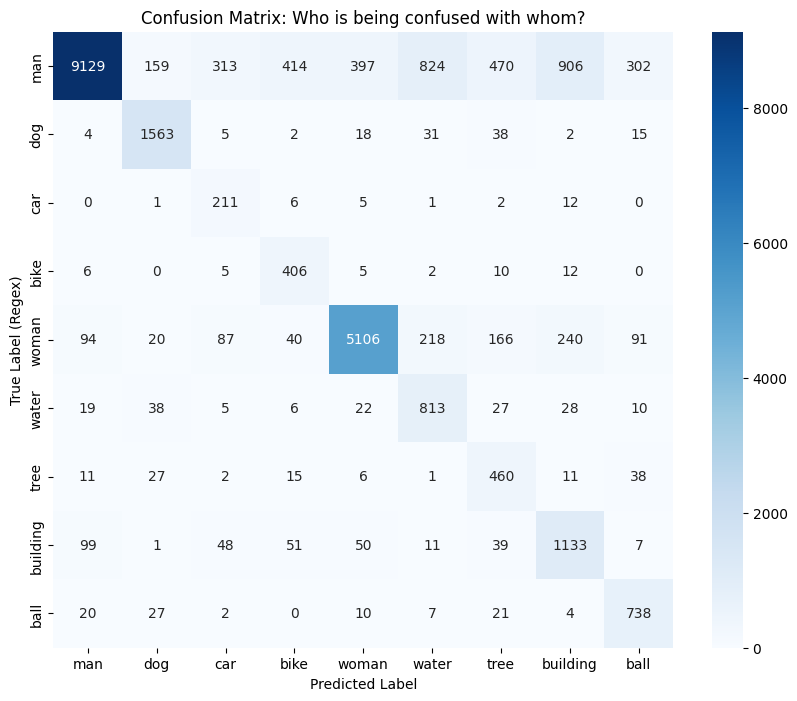


Tổng số mẫu sai: 5586 / 25145

--- TOP 10 HIGH-CONFIDENCE ERRORS (Model rất tự tin nhưng sai so với nhãn Regex) ---
                                                                                                          path                                                                                                                                           caption  label pred_label  confidence
2838   /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images/3420660565.jpg                        four people are sitting on blue and green couches while a fifth man sitting aside looks on underneath a sprawling red tree    man       tree    0.999955
11420  /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images/2072040759.jpg                                                                        three men and a woman posing on and around a large tree with many branches    man       tree    0.999859
15391  /kaggle/input/d

In [29]:
from sklearn.metrics import confusion_matrix

def perform_error_analysis(X_test, y_test, y_pred, clf, target_classes, df_test):
    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred, labels=target_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_classes, yticklabels=target_classes, cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label (Regex)')
    plt.title('Confusion Matrix: Who is being confused with whom?')
    plt.show()

    # TRÍCH XUẤT CÁC MẪU DỰ ĐOÁN SAI (MISCLASSIFIED)
    # Tính xác suất (confidence) cho từng dự đoán
    y_probs = clf.predict_proba(X_test)
    
    analysis_df = df_test.copy()
    analysis_df['pred_label'] = y_pred
    # Lấy xác suất của lớp được dự đoán
    analysis_df['confidence'] = [max(prob) for prob in y_probs]
    
    # Lọc ra các dòng sai
    errors = analysis_df[analysis_df['label'] != analysis_df['pred_label']].copy()
    # Sắp xếp theo độ tự tin giảm dần
    errors = errors.sort_values(by='confidence', ascending=False)

    print(f"\nTổng số mẫu sai: {len(errors)} / {len(df_test)}")
    print("\n--- TOP 10 HIGH-CONFIDENCE ERRORS (Model rất tự tin nhưng sai so với nhãn Regex) ---")
    # Hiển thị các cột quan trọng để kiểm tra thủ công
    display_cols = ['path', 'caption', 'label', 'pred_label', 'confidence']
    print(errors[display_cols].head(10).to_string())

    return errors

error_df = perform_error_analysis(X_test, y_test, y_pred, best_clf, TARGET_CLASSES, df_test)

### 1. Đánh giá hiệu năng tổng quát
Mô hình Few-shot với 128 shots đã cải thiện đáng kể so với Zero-shot, đạt **Accuracy $77,78\%$** và **Macro-F1 $0,67$**. Tuy nhiên, ta quan sát thấy một sự phân hóa cực đoan trong bảng chỉ số:
* **Các lớp chủ thể động (`man`, `woman`, `dog`):** Đạt Precision rất cao (lên tới $0,97$ cho lớp `man`). Điều này chứng tỏ đặc trưng của con người và vật nuôi trong không gian CLIP là cực kỳ tách biệt.
* **Các lớp bối cảnh (`tree`, `water`, `building`, `bike`):** Có Recall rất cao (thường $>0,80$) nhưng Precision lại thấp ($0,13$ - $0,48$). 

**Nhận định:** Mô hình đang bị hiện tượng "nhạy cảm thái quá" với bối cảnh. Khi một bức ảnh có sự xuất hiện của cây cối hoặc mặt nước, mô hình có xu hướng ưu tiên gán nhãn môi trường thay vì chủ thể người, dẫn đến việc "nuốt chửng" Recall của lớp `man`.

### 2. Nghịch lý về Độ tự tin (High-Confidence Paradox)
Kết quả phân tích 10 mẫu sai số có độ tự tin cao nhất là một bằng chứng đanh thép cho sự thất bại của phương pháp gán nhãn bằng từ khóa (Regex):

* **Sự áp đảo của Tiêu điểm thị giác (Visual Salience):** * Tại mẫu số `2838` và `11420`, mô hình đạt độ tự tin gần như tuyệt đối ($0,9999$) khi dự đoán nhãn `tree`, trong khi nhãn Regex là `man`. 
    * *Phân tích:* Caption mô tả người ngồi dưới một "sprawling red tree" hoặc quanh một "large tree". Với CLIP, một thực thể chiếm diện tích lớn và có màu sắc đặc trưng (như cây đỏ) sẽ tạo ra kích thích thị giác mạnh hơn chủ thể người. Ở đây, mô hình không "sai", nó chỉ đang phản ánh thực tế thị giác mà Regex đã bỏ qua.
* **Lỗi định danh đối tượng (Object vs. Subject):**
    * Mẫu số `16334`: "A girl sits on a decorated bike". Regex chọn `woman`, mô hình chọn `bike` ($Confidence = 0,9997$). 
    * *Phân tích:* Đây là bài toán đa thực thể. Việc cưỡng ép đơn nhãn khiến mô hình bị phạt một cách oan uổng khi nó nhận diện đúng vật thể trung tâm của hành động.

### 3. Nguyên nhân 
Ta xác định hai nguyên nhân chính:
1. **Nhiễu nhãn hệ thống:** Độ tự tin $>0,999$ cho các mẫu sai cho thấy mô hình đã học được các đặc trưng rất sạch, nhưng nhãn "Ground Truth" (từ Regex) lại bị sai lệch so với trọng tâm ảnh. Chúng ta đang dùng một bộ nhãn yếu (Weak Labels) để đánh giá một bộ trích xuất đặc trưng mạnh (CLIP).
2. **Sự mất cân bằng giữa Đặc trưng và Regularization:** Việc sử dụng $C=100,0$ là một quyết định mạo hiểm. Hệ số Regularization quá yếu khiến mô hình bám sát vào các đặc trưng bối cảnh của tập Train, dẫn đến việc nó "tự tin thái quá" vào những dự đoán mà thực chất là nhãn nhiễu.

### 4. Đề xuất cải tiến
Để nâng tầm công trình này, ta cần thực hiện các điều chỉnh sau:
* **Lọc dữ liệu dựa trên Consensus (Sự đồng thuận):** Loại bỏ các mẫu có sự mâu thuẫn giữa CLIP và Regex với Confidence $>0,95$. Những mẫu này thực chất là "rác" gây nhiễu cho quá trình học.
* **Chuyển đổi sang Top-K Accuracy:** Với dữ liệu đa thực thể như Flickr30k, việc đánh giá dựa trên Top-1 Accuracy là quá khắt khe. Ta nên bổ sung chỉ số Top-3 để phản ánh đúng khả năng nhận diện đa lớp của CLIP.
* **Điều chỉnh chiến thuật Regularization:** Chuyển sang $C$ nhỏ hơn (ví dụ $1.0$ hoặc $0.1$) để giảm bớt sự tự tin vào các đặc trưng bối cảnh, giúp mô hình cân bằng lại giữa chủ thể và môi trường.
